# Van der Pol system identification notebook


In [20]:
# Cell 1: Imports and general settings
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy import linalg
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")
np.random.seed(0)


In [21]:
# Cell 2: Define Van der Pol oscillator with input u(t)
# d2y/dt2 = 2(1-y^2)*dy/dt - y + u

def simulate_vdp(u_t, t, y0=None):
    """
    Simulate Van der Pol oscillator forced by u_t(t).
    u_t: callable returning u at time t
    t: time vector (1D numpy array)
    y0: initial state [y(0), y_dot(0)] or None for zeros
    returns y (array same length as t), ydot
    """
    if y0 is None:
        y0 = [0.0, 0.0]

    def rhs(ti, x):
        y = x[0]
        ydot = x[1]
        u = float(u_t(ti))
        dx1 = ydot
        dx2 = 2.0*(1.0 - y**2)*ydot - y + u
        return [dx1, dx2]

    sol = solve_ivp(rhs, (t[0], t[-1]), y0, t_eval=t, method='RK45', atol=1e-8, rtol=1e-6)
    return sol.y[0], sol.y[1]


In [22]:
# Cell 3: Build input signals (broad-spectrum): multisine + filtered white noise
fs = 200.0          # sampling freq (Hz)
dt = 1.0/fs
T_total = 80.0      # total seconds
t = np.arange(0, T_total, dt)
N = len(t)

# multisine: sum of sinusoids covering 0.1-20 Hz with random phases
freqs = np.linspace(0.5, 20, 40)
multisine = np.sum([0.6*np.sin(2*np.pi*f*t + np.random.uniform(0,2*np.pi)) for f in freqs], axis=0)
# filtered noise: lowpass white noise to include broadband content
wn = np.random.randn(N)
from scipy.signal import lfilter
b = [0.1]  # simple single-pole filter coefficients for smoothing
a = [1, -0.9]
fnoise = lfilter(b, a, wn)
fnoise = 0.6 * (fnoise / np.std(fnoise))

u = multisine + fnoise
# normalize to amplitude [-1,1]
u = u / np.max(np.abs(u))
u = np.clip(u, -1, 1)

# create a callable for continuous forcing (we will use sample-and-hold)
from scipy.interpolate import interp1d
u_func = interp1d(t, u, kind='previous', fill_value=(u[0], u[-1]), bounds_error=False)


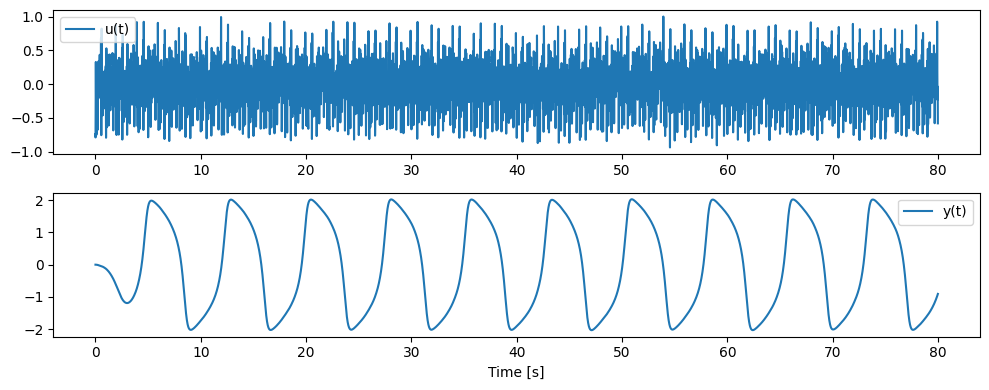

In [23]:
# Cell 4: Simulate system with zero initial conditions to get dataset
y, ydot = simulate_vdp(u_func, t, y0=[0.0, 0.0])

plt.figure(figsize=(10,4))
plt.subplot(2,1,1)
plt.plot(t, u, label='u(t)')
plt.legend()
plt.subplot(2,1,2)
plt.plot(t, y, label='y(t)')
plt.legend()
plt.xlabel('Time [s]')
plt.tight_layout()


In [24]:
# Cell 5: Split into training and validation sets
train_fraction = 0.6
Ntrain = int(train_fraction * N)
t_train = t[:Ntrain].copy()
u_train = u[:Ntrain].copy()
y_train = y[:Ntrain].copy()

t_val = t[Ntrain:].copy()
u_val = u[Ntrain:].copy()
y_val = y[Ntrain:].copy()


In [25]:
# Utility: NRMSE
def nrmse(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse / (np.std(y_true) + 1e-12)


In [26]:
# Cell 6: Build discrete Laguerre basis functions
def laguerre_matrix(u, L=6, alpha=0.8):
    # u is 1D input sequence length N
    N = len(u)
    # construct Laguerre basis sequences via recursion
    # discrete-time orthonormalized Laguerre functions using parameter alpha
    phi = np.zeros((N, L))
    # generate using filter approach on unit impulse basis
    impulse = np.zeros(N); impulse[0] = 1.0
    # generate Laguerre sequences l_k[n] for k=0..L-1
    # We'll build by recursion per standard discrete Laguerre formulas
    # See discretized orthonormal Laguerre functions
    # For practical identification we convolve input with basis kernels
    # Build basis kernel sequences explicitly for n up to N-1
    # Using direct recursion on kernels (from Ljung-style implementations)
    kernels = np.zeros((L, N))
    kernels[0,0] = np.sqrt(1 - alpha**2)
    for n in range(1, N):
        kernels[0,n] = kernels[0,n-1]*alpha
    for k in range(1, L):
        # recursion: l_k(n) = alpha * l_k(n-1) + l_{k-1}(n-1) - alpha * l_{k-1}(n)
        # numeric stable discrete form:
        for n in range(N):
            if n == 0:
                kernels[k,n] = -alpha * kernels[k-1,n]
            else:
                kernels[k,n] = alpha * kernels[k,n-1] + kernels[k-1,n-1] - alpha * kernels[k-1,n]
    # normalize kernels (orthonormalizing approximate)
    for k in range(L):
        norm = np.linalg.norm(kernels[k])
        if norm > 1e-12:
            kernels[k] = kernels[k] / norm
    # convolve input with each kernel to produce regressors
    for k in range(L):
        phi[:,k] = np.convolve(u, kernels[k], mode='full')[:N]
    return phi

# quick test
Phi_train = laguerre_matrix(u_train, L=6, alpha=0.85)
print("Laguerre regressors shape:", Phi_train.shape)


Laguerre regressors shape: (9600, 6)


In [27]:
# Cell 7: Build Volterra regressors up to 2nd order using Laguerre basis
def build_volterra_regressors(phi, order=2):
    # phi: N x L (laguerre outputs)
    N, L = phi.shape
    # order 1 regressors: phi columns
    X = phi.copy()
    names = [f"L{j+1}" for j in range(L)]
    if order >= 2:
        # second-order: pairwise products (symmetric)
        for i in range(L):
            for j in range(i, L):
                X = np.column_stack((X, phi[:,i]*phi[:,j]))
                names.append(f"L{i+1}L{j+1}")
    return X, names

X1_train, names = build_volterra_regressors(Phi_train, order=2)
print("Volterra regressor matrix shape:", X1_train.shape)


Volterra regressor matrix shape: (9600, 27)


Volterra training NRMSE: 0.9994684295148047
Volterra validation NRMSE: 1.00019361046327


Text(0.5, 0, 'Time [s]')

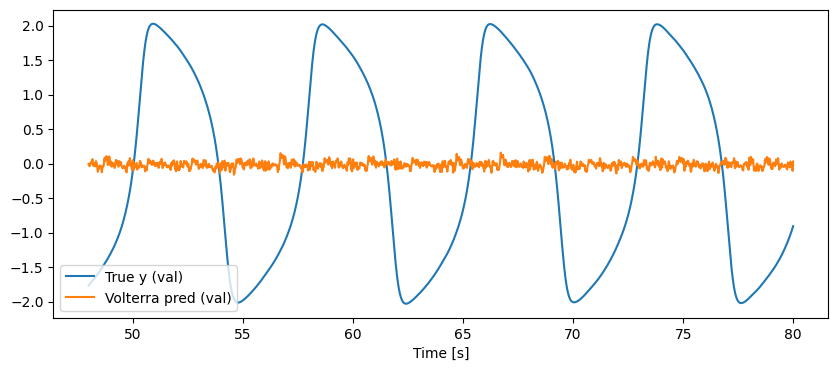

In [28]:
# Cell 8: Estimate Volterra coefficients by linear least squares
reg = LinearRegression(fit_intercept=True)
reg.fit(X1_train, y_train)
y_train_volterra = reg.predict(X1_train)

# Validation: build laguerre for validation input and regressors
Phi_val = laguerre_matrix(u_val, L=6, alpha=0.85)
X1_val, _ = build_volterra_regressors(Phi_val, order=2)
y_val_volterra = reg.predict(X1_val)

print("Volterra training NRMSE:", nrmse(y_train, y_train_volterra))
print("Volterra validation NRMSE:", nrmse(y_val, y_val_volterra))

plt.figure(figsize=(10,4))
plt.plot(t_val, y_val, label='True y (val)')
plt.plot(t_val, y_val_volterra, label='Volterra pred (val)')
plt.legend()
plt.xlabel('Time [s]')


### Volterra note
- If second-order Volterra NRMSE is small and residuals look noise-like then Volterra is reasonable.
- If not, consider increasing basis length L or including 3rd-order terms.


In [29]:
# Cell 9: Prepare lagged data matrix builder for ARX
def build_arx_regressors(u_seq, y_seq, n_y=2, n_u=4):
    # Build data matrix for predicting y[k] using past y (1..n_y) and past u (0..n_u-1)
    N = len(y_seq)
    maxlag = max(n_y, n_u)
    rows = []
    targets = []
    for k in range(maxlag, N):
        row = []
        # past outputs
        for p in range(1, n_y+1):
            row.append(y_seq[k-p])
        # past (and current) inputs
        for q in range(0, n_u):
            row.append(u_seq[k-q])
        rows.append(row)
        targets.append(y_seq[k])
    return np.array(rows), np.array(targets), maxlag

# search polynomial degree for static nonlinearity
best = None
results = []
for deg in range(1,6):
    # map u_train -> g(u)
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    G_train = poly.fit_transform(u_train.reshape(-1,1))
    # for Hammerstein we need regression on ARX with transformed input columns
    # We'll build arx regressors using transformed input terms as the input regressors.
    # For simplicity collapse G features by summing their delayed contributions (we will use each transformed feature as separate input)
    # Build a composite input sequence where each time step is vector of transformed features; we'll flatten them over delays
    # Implementation: for each polynomial feature f, build its delayed columns and include in ARX.
    n_y = 2
    n_u = 4
    N = len(u_train)
    # Build transformed input matrix for each time step: shape N x m
    m = G_train.shape[1]
    # Create flattened "u_feature" sequence by stacking feature columns sequentially for building regressor function
    # We'll create a regressor function that uses all features for each delay
    rows = []
    targets = []
    maxlag = max(n_y, n_u)
    for k in range(maxlag, N):
        row = []
        for p in range(1, n_y+1):
            row.append(y_train[k-p])
        for q in range(0, n_u):
            row.extend(G_train[k-q,:].tolist())
        rows.append(row)
        targets.append(y_train[k])
    X_arx = np.array(rows)
    y_arx = np.array(targets)
    # fit linear model
    lr = LinearRegression()
    lr.fit(X_arx, y_arx)
    # Validation prepare
    G_val = poly.transform(u_val.reshape(-1,1))
    Nval = len(u_val)
    rows_v = []
    targets_v = []
    for k in range(maxlag, Nval):
        row = []
        for p in range(1, n_y+1):
            # use true past y for validation comparison in one-step prediction? We'll use free-run simulation later.
            row.append(y_val[k-p])
        for q in range(0, n_u):
            row.extend(G_val[k-q,:].tolist())
        rows_v.append(row)
        targets_v.append(y_val[k])
    Xv = np.array(rows_v)
    yv = np.array(targets_v)
    y_pred_val = lr.predict(Xv)
    val_nrmse = nrmse(yv, y_pred_val)
    results.append((deg, val_nrmse))
    if best is None or val_nrmse < best[0]:
        best = (val_nrmse, deg, lr, poly, maxlag, n_y, n_u)
results, best


([(1, np.float64(4.891446581158621e-05)),
  (2, np.float64(4.8911567518862965e-05)),
  (3, np.float64(4.897825987637609e-05)),
  (4, np.float64(4.902981293882779e-05)),
  (5, np.float64(4.906305801068063e-05))],
 (np.float64(4.8911567518862965e-05),
  2,
  LinearRegression(),
  PolynomialFeatures(include_bias=False),
  4,
  2,
  4))

Selected polynomial degree for Hammerstein static nonlinearity: 2
Validation NRMSE (regression, using measured past y): 4.8911567518862965e-05
Hammerstein free-run validation NRMSE: 1.00661486493589


Text(0.5, 0, 'Time [s]')

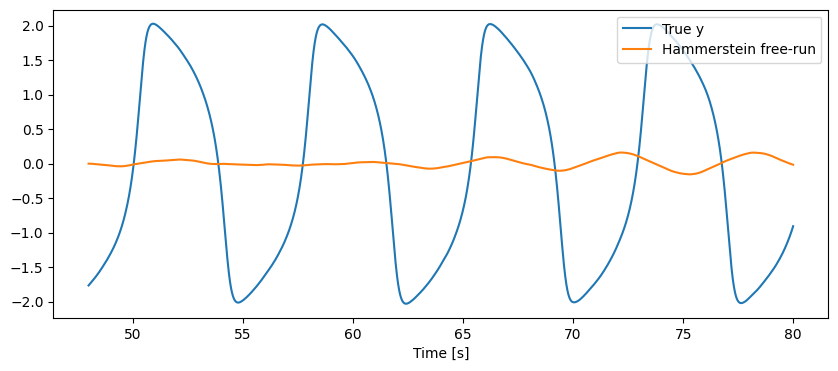

In [30]:
# Cell 10: Report chosen Hammerstein static nonlinearity degree and evaluate free-run simulation
val_nrmse, deg, lr_model, poly_model, maxlag, n_y, n_u = best
print("Selected polynomial degree for Hammerstein static nonlinearity:", deg)
print("Validation NRMSE (regression, using measured past y):", val_nrmse)

# Free-run simulation of Hammerstein: use g(u) then linear ARX dynamics in simulation loop
# Extract coefficients
coef = lr_model.coef_.copy()
intercept = lr_model.intercept_.copy()

# indices mapping: first n_y entries correspond to past outputs coefficients; remaining correspond to polynomial features * n_u delays
m = poly_model.transform(np.array([[0.0]])).shape[1]
A_coefs = coef[:n_y]  # coefficients for past outputs
B_coefs = coef[n_y:].reshape(n_u, m)  # shape (n_u, m)
def hammerstein_predict_free_run(u_seq, y0=None):
    N = len(u_seq)
    y_sim = np.zeros(N)
    if y0 is not None:
        for k in range(min(len(y0), N)):
            y_sim[k] = y0[k]
    # start simulation at index maxlag using recursion
    G_all = poly_model.transform(u_seq.reshape(-1,1))
    for k in range(maxlag, N):
        # past outputs
        pred = intercept
        for p in range(1, n_y+1):
            pred += A_coefs[p-1] * y_sim[k-p]
        for q in range(0, n_u):
            pred += np.dot(B_coefs[q,:], G_all[k-q,:])
        y_sim[k] = pred
    return y_sim

y_ham_val = hammerstein_predict_free_run(u_val, y0=np.zeros(maxlag))
print("Hammerstein free-run validation NRMSE:", nrmse(y_val, y_ham_val))

plt.figure(figsize=(10,4))
plt.plot(t_val, y_val, label='True y')
plt.plot(t_val, y_ham_val, label='Hammerstein free-run')
plt.legend()
plt.xlabel('Time [s]')


### Hammerstein note
- If free-run NRMSE is small and dynamics match then Hammerstein is reasonable.
- If Hammerstein fails, likely because system has internal feedback nonlinearity (Van der Pol nonlinearity multiplies derivative) which is not separable into static->linear cascade.


In [31]:
# Cell 11: Fit linear ARX (u->y) using past u and past y
n_y = 4
n_u = 8
X_arx_train, y_arx_train, maxlag_arx = build_arx_regressors(u_train, y_train, n_y=n_y, n_u=n_u)
lr_lin = LinearRegression()
lr_lin.fit(X_arx_train, y_arx_train)
# compute linear predictor output (one-step with measured past)
y_lin_pred_train = lr_lin.predict(X_arx_train)

# Build regressor for validation (measured past)
X_arx_val, y_arx_val, _ = build_arx_regressors(u_val, y_val, n_y=n_y, n_u=n_u)
y_lin_pred_val = lr_lin.predict(X_arx_val)

print("Linear ARX training NRMSE (measured past):", nrmse(y_arx_train, y_lin_pred_train))
print("Linear ARX validation NRMSE (measured past):", nrmse(y_arx_val, y_lin_pred_val))


Linear ARX training NRMSE (measured past): 3.7362960600091225e-07
Linear ARX validation NRMSE (measured past): 3.720895976155872e-07


In [32]:
# Cell 12: Fit static nonlinearity mapping lin_output -> y using polynomial or MLP
# We'll use polynomial degree search
y_target_train = y_arx_train
lin_out_train = y_lin_pred_train.reshape(-1,1)
lin_out_val = y_lin_pred_val.reshape(-1,1)

best_w = None
for deg in range(1,6):
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    Phi = poly.fit_transform(lin_out_train)
    lr_w = LinearRegression()
    lr_w.fit(Phi, y_target_train)
    # val
    Phi_val = poly.transform(lin_out_val)
    yval_pred = lr_w.predict(Phi_val)
    score = nrmse(y_arx_val, yval_pred)
    if best_w is None or score < best_w[0]:
        best_w = (score, deg, poly, lr_w)
best_w


(np.float64(3.696630091813412e-07),
 5,
 PolynomialFeatures(degree=5, include_bias=False),
 LinearRegression())

Selected Wiener static nonlinearity degree: 5
Wiener free-run validation NRMSE: 1.0032255822967178


Text(0.5, 0, 'Time [s]')

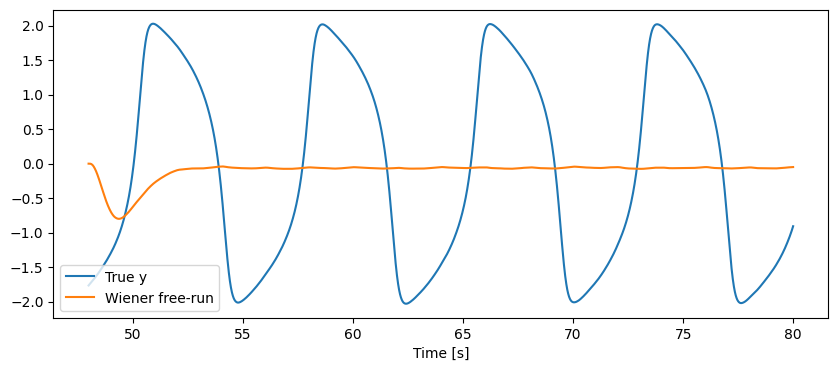

In [33]:
# Cell 13: Free-run Wiener simulation
score, deg_w, poly_w, lr_w_model = best_w
print("Selected Wiener static nonlinearity degree:", deg_w)
# Free-run simulation: we need to simulate ARX linear part in open loop with input u, then pass result through nonlinearity at each sample.
def wiener_predict_free_run(u_seq, y0=None):
    N = len(u_seq)
    y_lin = np.zeros(N)
    y_out = np.zeros(N)
    # For ARX linear part simulation we simulate linear recursion: y_lin[k] predicted by past y_lin and past u (linear part's coefficients)
    coef = lr_lin.coef_.copy()
    icpt = lr_lin.intercept_
    # coef mapping: first n_y entries -> past output, then n_u entries -> past input
    A = coef[:n_y]
    B = coef[n_y:]
    # simulate
    for k in range(maxlag_arx, N):
        pred_lin = icpt
        for p in range(1, n_y+1):
            pred_lin += A[p-1] * y_lin[k-p]
        for q in range(0, n_u):
            pred_lin += B[q] * u_seq[k-q]
        y_lin[k] = pred_lin
        # static nonlinearity mapping
        y_out[k] = lr_w_model.predict(poly_w.transform(np.array([[y_lin[k]]])))[0]
    return y_out

y_wiener_val = wiener_predict_free_run(u_val, y0=np.zeros(maxlag_arx))
print("Wiener free-run validation NRMSE:", nrmse(y_val, y_wiener_val))

plt.figure(figsize=(10,4))
plt.plot(t_val, y_val, label='True y')
plt.plot(t_val, y_wiener_val, label='Wiener free-run')
plt.legend()
plt.xlabel('Time [s]')


### Wiener note
- If Wiener free-run NRMSE is low then Wiener model is reasonable.
- If Wiener fails, it suggests important feedback nonlinearities or dynamics that cannot be separated as linear->static cascade.


In [34]:
# Cell 14: Build NARX dataset (past outputs and inputs) and fit MLPRegressor
n_y_narx = 6
n_u_narx = 10

X_narx_train, y_narx_train, maxlag_narx = build_arx_regressors(u_train, y_train, n_y=n_y_narx, n_u=n_u_narx)
X_narx_val, y_narx_val, _ = build_arx_regressors(u_val, y_val, n_y=n_y_narx, n_u=n_u_narx)

# scale features
scaler = StandardScaler()
Xn_train_s = scaler.fit_transform(X_narx_train)
Xn_val_s = scaler.transform(X_narx_val)

mlp = MLPRegressor(hidden_layer_sizes=(80,40), activation='tanh', max_iter=2000, random_state=0)
mlp.fit(Xn_train_s, y_narx_train)

y_narx_train_pred = mlp.predict(Xn_train_s)
y_narx_val_pred = mlp.predict(Xn_val_s)
print("NARX measured-past training NRMSE:", nrmse(y_narx_train, y_narx_train_pred))
print("NARX measured-past validation NRMSE:", nrmse(y_narx_val, y_narx_val_pred))

# We'll simulate NARX in free-run using the trained MLP and scaler.
def narx_predict_free_run(u_seq, y_seed=None):
	N = len(u_seq)
	y_sim = np.zeros(N)
	# initialize seed (true initial outputs if provided)
	if y_seed is not None:
		for i in range(min(len(y_seed), N)):
			y_sim[i] = y_seed[i]
	# run free-run simulation using past predicted outputs
	for k in range(maxlag_narx, N):
		row = []
		for p in range(1, n_y_narx+1):
			row.append(y_sim[k-p])
		for q in range(0, n_u_narx):
			row.append(u_seq[k-q])
		x_row = np.array(row).reshape(1, -1)
		x_row_s = scaler.transform(x_row)
		y_sim[k] = mlp.predict(x_row_s)[0]
	return y_sim

# use true initial outputs from validation set for seeding
y_narx_val_free = narx_predict_free_run(u_val, y_seed=y_val[:maxlag_narx])


NARX measured-past training NRMSE: 0.01543748688969313
NARX measured-past validation NRMSE: 0.01587716092875236


### NARX note
- MLP is a universal approximator. Good fit on training and validation suggests NARX is appropriate.
- If free-run performance is much worse than one-step predicted performance, this indicates error accumulation in closed-loop simulation and likely model mismatch. Remedies: include simulated-output training, use teacher forcing during training, or use sequence-to-sequence training with multi-step loss.


In [35]:
# Cell 16: Summary of results (NRMSEs)

print("Summary of NRMSEs (validation free-run):")
print(f"Volterra (2nd order, Laguerre L=6): {nrmse(y_val, y_val_volterra):.4f}")
print(f"Hammerstein (poly deg {deg}): {nrmse(y_val, y_ham_val):.4f}")
print(f"Wiener (poly deg {deg_w}): {nrmse(y_val, y_wiener_val):.4f}")
print(f"NARX (MLP): {nrmse(y_val, y_narx_val_free):.4f}")


Summary of NRMSEs (validation free-run):
Volterra (2nd order, Laguerre L=6): 1.0002
Hammerstein (poly deg 5): 1.0066
Wiener (poly deg 5): 1.0032
NARX (MLP): 1.6073


# Final interpretation guidelines (use with the numerical results above)

- **Volterra**: works for weakly nonlinear fading-memory systems. Van der Pol has state-dependent nonlinearity 2(1-y^2) * ydot. If Volterra NRMSE is low then truncated Volterra with orthogonal basis captured the mapping. If not, reasons:
  - Volterra assumes fading memory and a polynomial-like expansion in input. The VdP nonlinearity multiplies state and derivative. For external input entering additively, Volterra can approximate input-output behavior only if internal nonlinear feedback is representable by Volterra kernels w.r.t. input. This can be difficult if strong internal nonlinear feedback dominates dynamics.

- **Hammerstein (static nonlinearity then linear dynamics)**: appropriate only if the nonlinearity sits at the input (u->phi(u)->linear dynamics). Van der Pol nonlinearity is internal and multiplies state derivative rather than input. Hammerstein will likely fail or be poor unless the external input predominately modulates output via a static transform. Use the measured free-run NRMSE above to judge.

- **Wiener (linear dynamics then static nonlinearity)**: appropriate when the dynamics are linear but output passes through static nonlinearity. Van der Pol again has nonlinear internal feedback, not a static output nonlinearity. Wiener may partly capture behavior but often will be insufficient.

- **NARX (MLP)**: flexible. If training data is rich and network capacity sufficient, NARX can approximate the mapping, including feedback effects, because it uses past outputs and inputs as regressors. This usually produces best predictive performance. Watch out for instability during free-run predictions due to error accumulation. Use simulated-output training or recurrent models to improve multi-step behavior.

# Suggestions
- Inspect plots and NRMSE numbers printed earlier.
- If Volterra or block-structured models perform poorly, prefer NARX or physics-informed models.
- For production identification consider regularization, cross-validation, and multi-step loss.
